# 04. Seaborn Statistical Distribution & Relational Plotting: Beginner Guide

### 📌 Overview & Architectural Context
Welcome to **04. Seaborn Statistical Distribution & Relational Plotting**. Seaborn builds high-level statistical plotting abstractions on top of Matplotlib, natively integrating with Pandas DataFrames. This notebook covers relational plotting (`scatterplot`, `lineplot`), distribution modeling (`histplot`, `kdeplot`, `ecdfplot`), categorical distributions (`boxplot`, `violinplot`, `stripplot`), and figure-level vs axes-level functions.

### 📚 Key Concepts Covered in this Notebook:
- [x] 🔹 Distribution Histogram: `sns.histplot()`
- [x] 🔹 Kernel Density Estimation: `sns.kdeplot()`
- [x] 🔹 Boxplots: `sns.boxplot()`
- [x] 🔹 Violin Plots: `sns.violinplot()`
- [x] 🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`
- [x] 🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`
- [x] 🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`
- [x] 🔹 Linear Regression Best-Fit: `sns.regplot()`


In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14251 transactions from ../data/raw_transactions.csv


,transaction_id,customer_id,merchant_id,transaction_amount,card_type,transaction_status,device_type,account_age_months,transaction_date,region,is_fraud
0,TX109326,C55082,M3549,607.78,Visa,Reversed,Mobile,8,2026-02-17 08:28:57,North,0
1,TX106376,C76616,M3068,1819.11,Visa,Pending,POS,28,2025-01-03 00:00:00,West,1
2,TX103301,C65296,M3352,64.08,Visa,Completed,Mobile,91,2025-12-20 00:00:00,East,0


### 🔹 Distribution Histogram: `sns.histplot()`
- **What it does:** Plots univariate or bivariate histograms to show distributions of datasets with optional KDE density curves.
- **Syntax:** `sns.histplot(data=None, *, x=None, y=None, hue=None, weights=None, stat='count', bins='auto', binwidth=None, binrange=None, discrete=None, cumulative=False, common_bins=True, common_norm=True, multiple='layer', element='bars', fill=True, shrink=1, kde=False, kde_kws=None, line_kws=None, thresh=0, pthresh=None, pmax=None, cbar=False, cbar_ax=None, cbar_kws=None, palette=None, hue_order=None, hue_norm=None, color=None, log_scale=None, legend=True, ax=None, **kwargs)`
- **Key Note:** Setting `kde=True` overlays a smooth Gaussian kernel density curve directly onto the histogram bars.
- **Dataset Application & Code Demonstration:** Applies Distribution Histogram on fintech records using columns `card_type`, `transaction_amount` to demonstrate real-world execution.


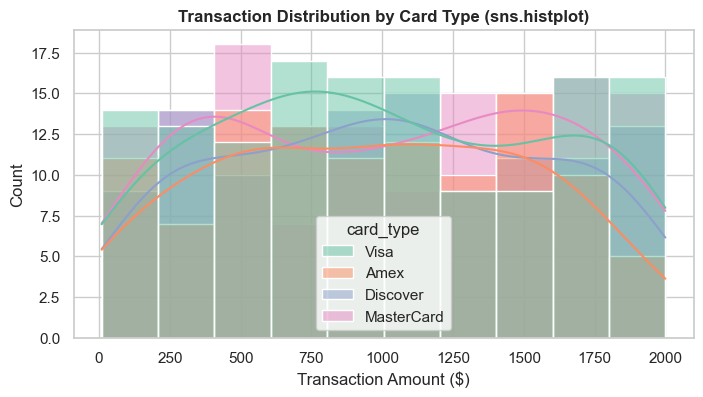

In [2]:
# 1. Plot amount distribution with a smooth curve
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.head(500), x='transaction_amount', hue='card_type', kde=True, ax=ax, palette='Set2')
ax.set_title('Transaction Distribution by Card Type (sns.histplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

### 🔹 Kernel Density Estimation: `sns.kdeplot()`
- **What it does:** Demonstrates how to use `🔹 Kernel Density Estimation: `sns.kdeplot()`` in Python.
- **Syntax:** `sns.kdeplot()`
  - **Parameters:**
    - `row_label` (*hashable*): Row label.
    - `col_label` (*hashable*): Column label.
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Kernel Density Estimation on fintech records using columns `is_fraud`, `transaction_amount` to demonstrate real-world execution.


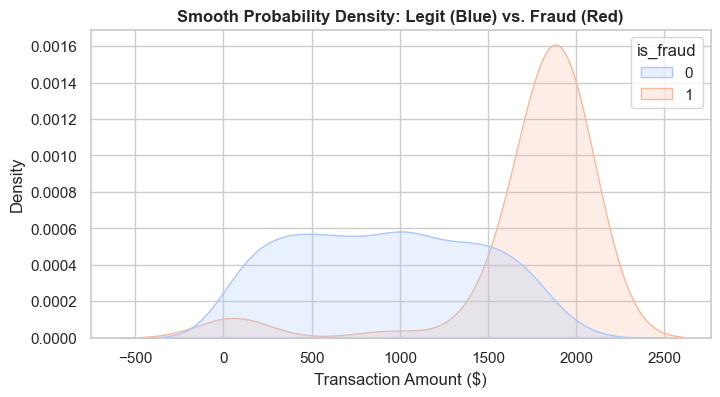

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df.head(500), x='transaction_amount', hue='is_fraud', fill=True, common_norm=False, palette='coolwarm', ax=ax)
ax.set_title('Smooth Probability Density: Legit (Blue) vs. Fraud (Red)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

### 🔹 Boxplots: `sns.boxplot()`
- **What it does:** Demonstrates how to use `🔹 Boxplots: `sns.boxplot()`` in Python.
- **Syntax:** `sns.boxplot()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Boxplots on fintech records using columns `card_type`, `is_fraud`, `transaction_amount` to demonstrate real-world execution.


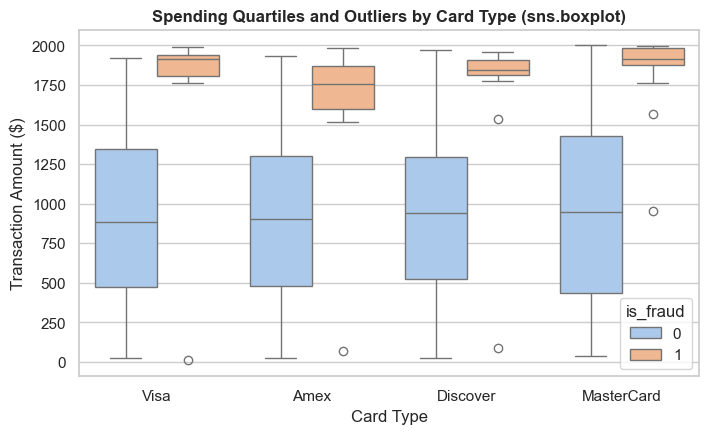

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', palette='pastel', ax=ax)
ax.set_title('Spending Quartiles and Outliers by Card Type (sns.boxplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 Violin Plots: `sns.violinplot()`
- **What it does:** Demonstrates how to use `🔹 Violin Plots: `sns.violinplot()`` in Python.
- **Syntax:** `sns.violinplot()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Violin Plots on fintech records using columns `card_type`, `is_fraud`, `transaction_amount` to demonstrate real-world execution.


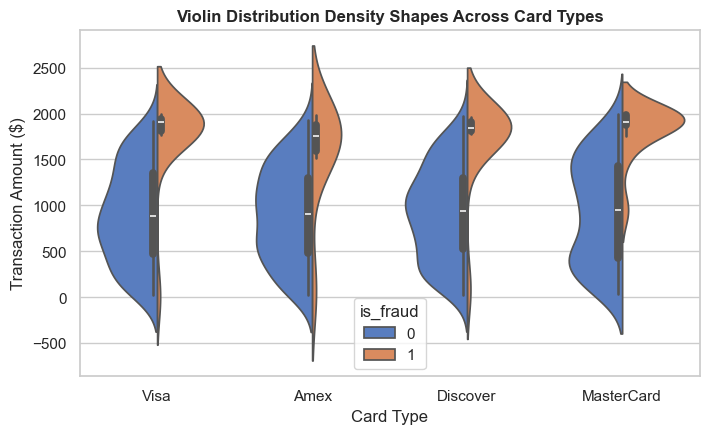

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', split=True, palette='muted', ax=ax)
ax.set_title('Violin Distribution Density Shapes Across Card Types', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`
- **What it does:** Demonstrates how to use `🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`` in Python.
- **Syntax:** `sns.stripplot()`
  - **Parameters:**
    - `row_label` (*hashable*): Row label.
    - `col_label` (*hashable*): Column label.
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Categorical Strip & Swarm Plots on fintech records using columns `region`, `transaction_amount` to demonstrate real-world execution.


C:\Users\DELL\AppData\Local\Temp\ipykernel_10528\3841993190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)


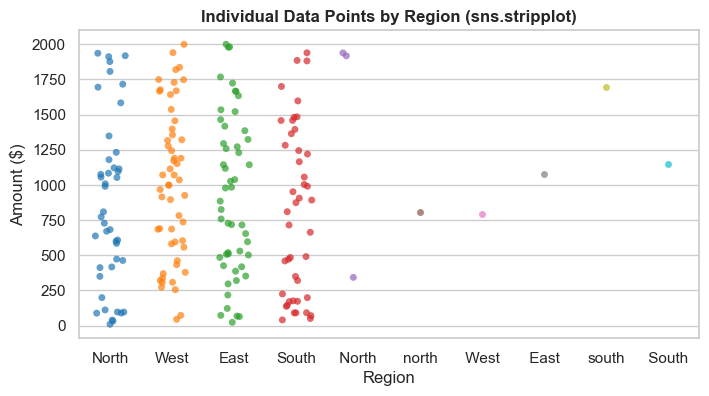

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)
ax.set_title('Individual Data Points by Region (sns.stripplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')

plt.show()

### 🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`
- **What it does:** Demonstrates how to use `🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`` in Python.
- **Syntax:** `sns.barplot()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Bar Plot with 95% Confidence Intervals on fintech records using columns `is_fraud`, `region`, `transaction_amount` to demonstrate real-world execution.


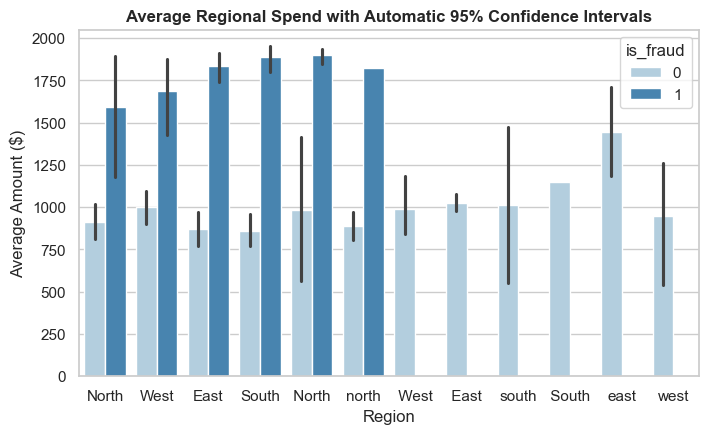

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(df.head(500), x='region', y='transaction_amount', hue='is_fraud', palette='Blues', ax=ax)
ax.set_title('Average Regional Spend with Automatic 95% Confidence Intervals', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average Amount ($)')

plt.show()

### 🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`
- **What it does:** Demonstrates how to use `🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`` in Python.
- **Syntax:** `sns.scatterplot()`
  - **Parameters:**
    - `row_label` (*hashable*): Row label.
    - `col_label` (*hashable*): Column label.
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Scatter Plot with Multi-Encoding on fintech records using columns `account_age_months`, `card_type`, `is_fraud`, `transaction_amount` to demonstrate real-world execution.


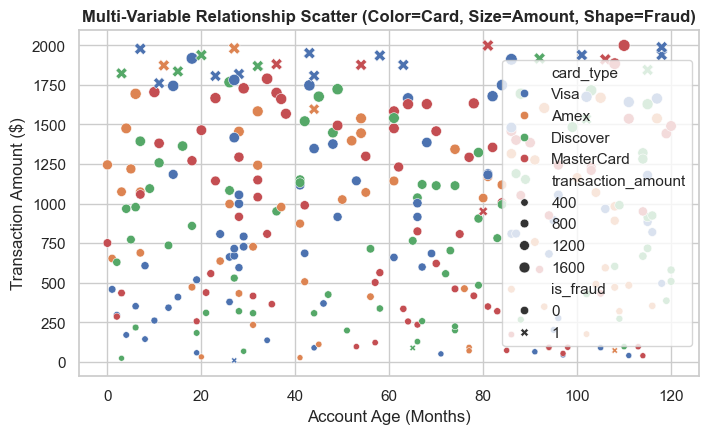

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(
    data=df.head(300), 
    x='account_age_months', 
    y='transaction_amount', 
    hue='card_type', 
    size='transaction_amount', 
    style='is_fraud', 
    ax=ax
)
ax.set_title('Multi-Variable Relationship Scatter (Color=Card, Size=Amount, Shape=Fraud)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 Linear Regression Best-Fit: `sns.regplot()`
- **What it does:** Demonstrates how to use `🔹 Linear Regression Best-Fit: `sns.regplot()`` in Python.
- **Syntax:** `sns.regplot()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Linear Regression Best-Fit on fintech records using columns `account_age_months`, `transaction_amount` to demonstrate real-world execution.


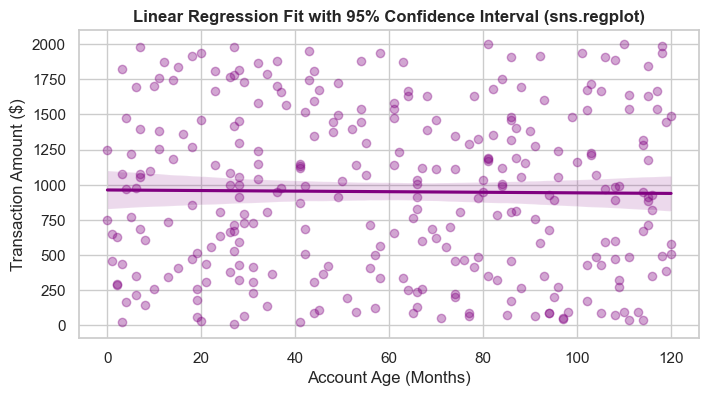

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.regplot(data=df.head(300), x='account_age_months', y='transaction_amount', color='purple', scatter_kws={'alpha':0.35}, ax=ax)
ax.set_title('Linear Regression Fit with 95% Confidence Interval (sns.regplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()